In [1]:
## Freshwater budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree
    # Desnity of freshwater: 1000 Kg/m3
    # Reference salinity: 34.8 g/kg
    # Assume constant mixed layer salinity
    

In [2]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

C:\Users\TomAH\anaconda3\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 13

In [4]:
## Open 5 Day means to compute delta FC acrosss the month
catalog = OceanDataCatalog(catalog_name="noc-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to bounding box
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y
              Title: T1y Icechunk repository
              Description: **Annual mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1y')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m
              Title: T1m Icechunk repository
              Description: **Monthly mean global ocean physics outputs defined at NEMO model T-points.**

**OceanDataCatalog Access:**
`catalog.open_dataset(id='noc-npd-era5/npd-eorca1-era5v1/r1i1c1f1/gn/T1m')`
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/r1i1c1f1/gn/T1y_3d
       

In [2]:
dt

NameError: name 'dt' is not defined

In [4]:
# Compute time series of dFC/dT

dt['gridT']['Freshwater Content'] = ((34.8 - dt['gridT']['sos_abs'])/34.8) * 50
FC_ts = (dt.integral(grid='gridT', var='Freshwater Content', dims=['i', 'j']))
delta_FC = FC_ts.resample(time_counter='ME').map(lambda x: x.isel(time_counter=-1) - x.isel(time_counter=0))
days_in_month = FC_ts.resample(time_counter='ME').map(lambda x: x.time_counter[-1].dt.day - x.time_counter[0].dt.day)
seconds_in_month = days_in_month * 24 * 60 * 60
dFCbydt = (delta_FC / seconds_in_month).compute()

In [5]:
FC_monthly = FC_ts.resample(time_counter = 'ME').mean()

In [8]:
FC_monthly = FC_monthly.compute()

In [9]:
# Save Terms

dFCbydt.to_netcdf('dFCbydt_50m.nc')
FC_monthly.to_netcdf('FC_50m.nc')

In [4]:
# Start from here 

dFCbydt = xr.open_dataset('dFCbydt_50m.nc')['__xarray_dataarray_variable__']
surface_flux = xr.open_dataset('surface_flux_again.nc')['sowaflup']
integrated_MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']
FC = xr.open_dataset('FC_50m.nc')['Freshwater Content']
SSSs = xr.open_dataset('Integrated_SSS.nc')['sos_abs']
SSSvals = SSSs.values


In [5]:
residuals = dFCbydt - surface_flux
magnitude_ratios = abs(surface_flux) / abs(residuals)
heatflux_contribution = surface_flux / dFCbydt

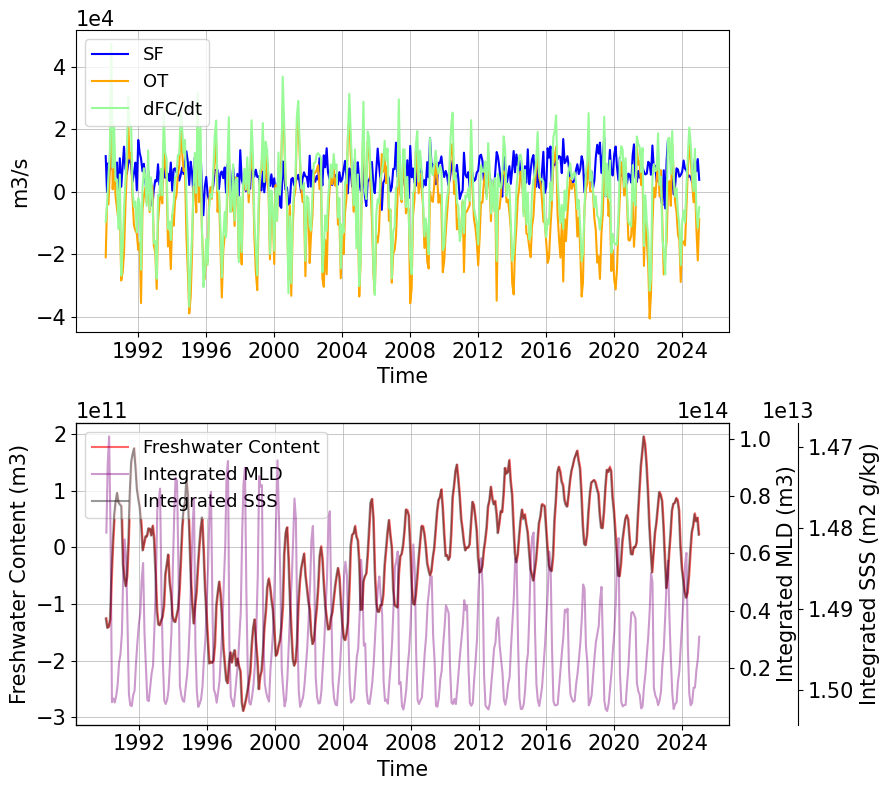

In [7]:
# Surface freshwater flux vs Advwection vs dFC/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(surface_flux['time_counter'], surface_flux, color = 'b', label = 'SF')
ax1.plot(residuals['time_counter'], residuals, color = 'orange', label = 'OT')
ax1.plot(dFCbydt['time_counter'], dFCbydt, color = '#98FB98', label = 'dFC/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('m3/s')
ax1.grid(True, which='both', linewidth=0.5)
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

l1 = ax2.plot(FC['time_counter'], FC, label = 'Freshwater Content', color = 'r', alpha = 0.6)
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple', alpha = 0.4)
l3 = ax4.plot(SSSs['time_counter'], SSSs, label = 'Integrated SSS', color = 'k', alpha = 0.4)
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.set_xlabel('Time')
ax2.set_ylabel('Freshwater Content (m3)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SSS (m2 g/kg)')
ax2.legend(lines, labels, loc='upper left')
ax4.invert_yaxis()
ax2.grid(True, which='both', linewidth=0.5)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 

plt.tight_layout()
plt.show()

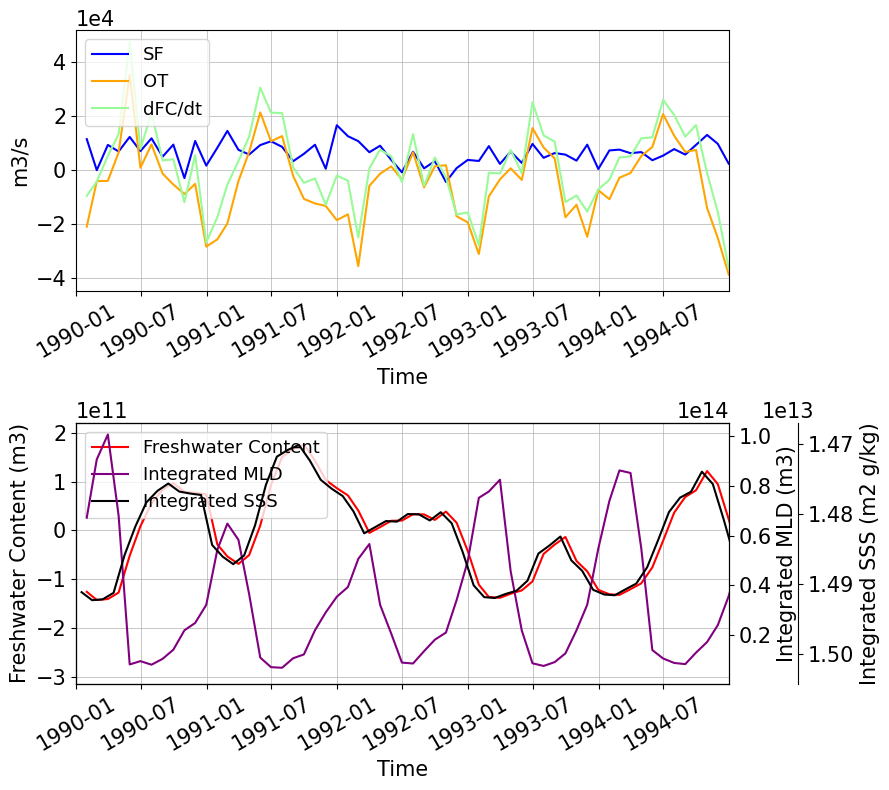

In [8]:
# Surface freshwater flux vs Advwection vs dFC/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(surface_flux['time_counter'], surface_flux, color = 'b', label = 'SF')
ax1.plot(residuals['time_counter'], residuals, color = 'orange', label = 'OT')
ax1.plot(dFCbydt['time_counter'], dFCbydt, color = '#98FB98', label = 'dFC/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('m3/s')
ax1.set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax1.grid(True, which='both', linewidth=0.5)
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax1.tick_params(axis = 'x', labelrotation = 30)

l1 = ax2.plot(FC['time_counter'], FC, label = 'Freshwater Content', color = 'r')
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
l3 = ax4.plot(SSSs['time_counter'], SSSs, label = 'Integrated SSS', color = 'k')
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.set_xlabel('Time')
ax2.set_ylabel('Freshwater Content (m3)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SSS (m2 g/kg)')
ax2.legend(lines, labels, loc='upper left')
ax4.invert_yaxis()
ax2.set_xlim(np.datetime64('1990-01-01'), np.datetime64('1994-12-31'))
ax2.grid(True, which='both', linewidth=0.5)
ax2.tick_params(axis = 'x', labelrotation = 30)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 


plt.tight_layout()
plt.show()

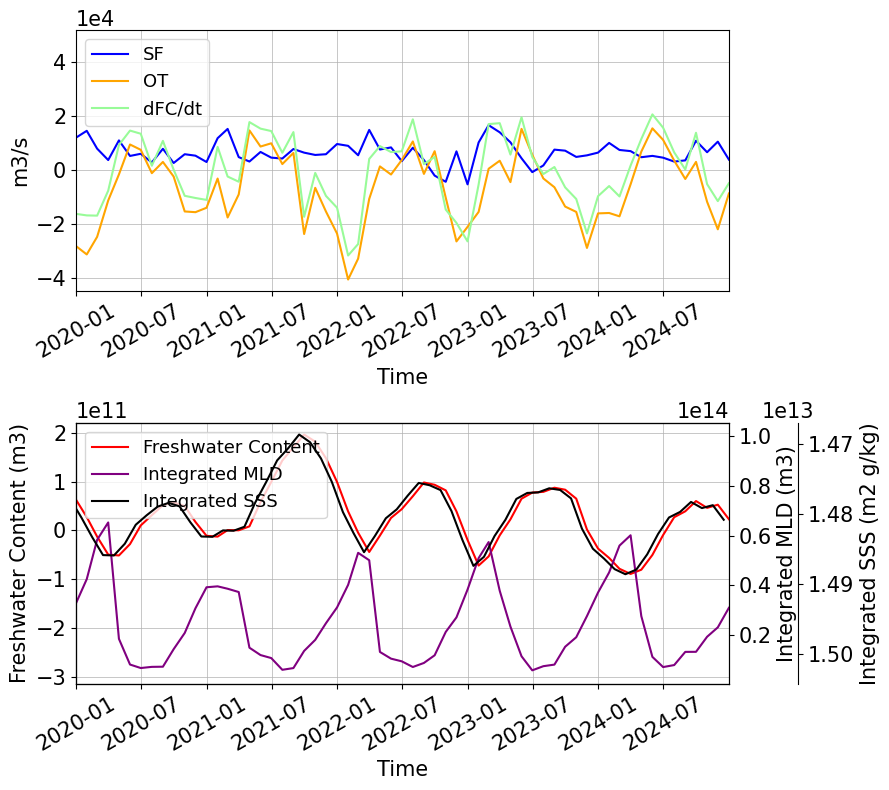

In [9]:
# Surface freshwater flux vs Advwection vs dFC/dt 

fig, ax = plt.subplots(2, 1, figsize = (9, 8))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax2.twinx()
ax4 = ax2.twinx()
ax4.spines["right"].set_position(("outward", 50))

ax1.plot(surface_flux['time_counter'], surface_flux, color = 'b', label = 'SF')
ax1.plot(residuals['time_counter'], residuals, color = 'orange', label = 'OT')
ax1.plot(dFCbydt['time_counter'], dFCbydt, color = '#98FB98', label = 'dFC/dt')
ax1.legend(loc = 'upper left')
ax1.set_xlabel('Time')
ax1.set_ylabel('m3/s')
ax1.set_xlim(np.datetime64('2020-01-01'), np.datetime64('2024-12-31'))
ax1.grid(True, which='both', linewidth=0.5)
ax1.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax1.tick_params(axis = 'x', labelrotation = 30)

l1 = ax2.plot(FC['time_counter'], FC, label = 'Freshwater Content', color = 'r')
l2 = ax3.plot(integrated_MLD['time_counter'], integrated_MLD, label = 'Integrated MLD', color = 'purple')
l3 = ax4.plot(SSSs['time_counter'], SSSs, label = 'Integrated SSS', color = 'k')
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax2.set_xlabel('Time')
ax2.set_ylabel('Freshwater Content (m3)')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('Integrated SSS (m2 g/kg)')
ax2.legend(lines, labels, loc='upper left')
ax4.invert_yaxis()
ax2.set_xlim(np.datetime64('2020-01-01'), np.datetime64('2024-12-31'))
ax2.grid(True, which='both', linewidth=0.5)
ax2.tick_params(axis = 'x', labelrotation = 30)
ax4.yaxis.set_offset_position('right')
ax4.yaxis.get_offset_text().set_x(1.13) 

plt.tight_layout()
plt.show()

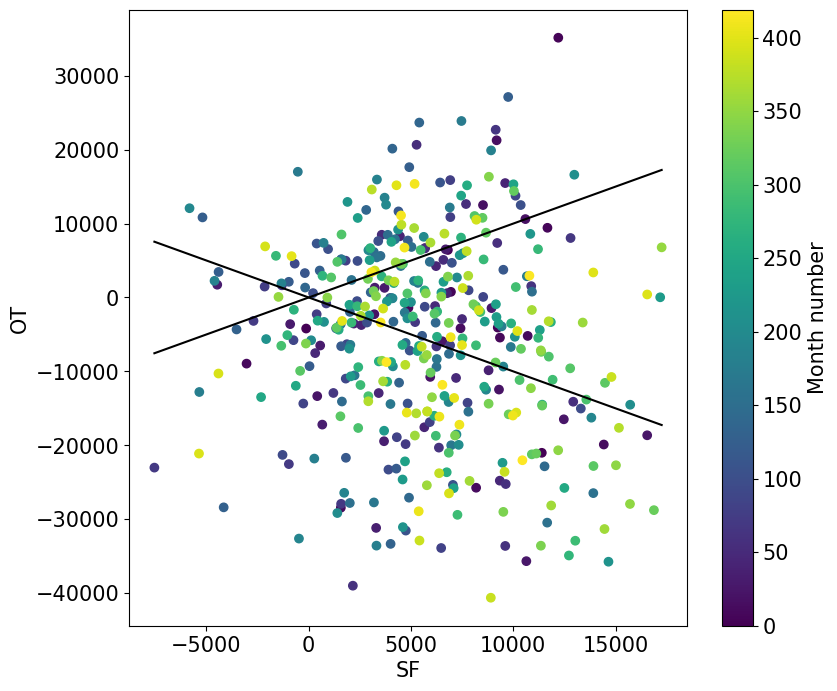

In [14]:
# Josey and Sinha Plot
progression = np.arange(len(surface_flux))

fig, ax = plt.subplots(figsize = (9, 8))

plt.scatter(surface_flux.values, residuals.values, c = progression, cmap = 'viridis')
plt.xlabel('SF')
plt.ylabel('OT')

xmin = surface_flux.min().item()
xmax = surface_flux.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
plt.colorbar(ax = ax, label = ('Month number'))

plt.show()

In [10]:
print(f'dFCbydt standard deviation: {(dFCbydt.std(dim='time_counter')).values}')
print(f'Surface flux standard deviation: {(surface_flux.std(dim='time_counter')).values}')
print(f'advection, entrainment, diffusion standard deviation: {(residuals.std(dim='time_counter')).values}')

dFCbydt standard deviation: 13353.039545146481
Surface flux standard deviation: 4420.428485653661
advection, entrainment, diffusion standard deviation: 13133.024955436349


In [17]:
print('------1990-1995------')
print(f'dFWCbydt standard deviation: {(dFCbydt.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print(f'Surface flux standard deviation: {(surface_flux.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print(f'advection, entrainment, diffusion standard deviation: {(residuals.isel(time_counter = slice(0, 60)).std(dim='time_counter')).values:.3e}')
print('------2020-2025------')
print(f'dFWCbydt standard deviation: {(dFCbydt.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')
print(f'Surface flux standard deviation: {(surface_flux.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')
print(f'Advection, entrainment, diffusion standard deviation: {(residuals.isel(time_counter = slice(360, 420)).std(dim='time_counter')).values:.3e}')

------1990-1995------
dFWCbydt standard deviation: 1.506e+04
Surface flux standard deviation: 4.222e+03
advection, entrainment, diffusion standard deviation: 1.426e+04
------2020-2025------
dFWCbydt standard deviation: 1.295e+04
Surface flux standard deviation: 4.222e+03
Advection, entrainment, diffusion standard deviation: 1.304e+04
